**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
import xgboost as xgb
from sklearn.model_selection import  RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Chargement du fichier
df_knn =  pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
df = pd.read_csv(r'C:\Users\meria\Downloads\mlProject\dataset_reduit.csv')
print(f"Shape: {df.shape}")
print(f"Colonnes: {list(df.columns)}")
print("\nAperçu des 5 premières lignes :")
df.head()

Shape: (30000, 21)
Colonnes: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'Job_Title', 'Growth_Category', 'AI_Impact_Level']

Aperçu des 5 premières lignes :


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,Job_Title,Growth_Category,AI_Impact_Level
0,-0.013697,-1.297713,-1.309655,-1.020011,-0.678511,-1.115369,-1.902685,1.476980,0.035599,1.823552,...,-1.146481,-0.807587,0.034256,-0.614458,0.535987,-0.346150,-0.308290,investment analyst,high_growth,moderate
1,-1.726004,2.444325,1.379046,0.950426,0.470645,0.336191,1.093795,-1.638459,-0.945801,2.236097,...,-0.491355,-0.593537,-0.997776,0.453375,0.467345,1.738559,-0.366865,"journalist, newspaper",high_growth,moderate
2,1.230255,0.140822,-1.822413,0.399887,-1.386898,0.966564,0.292732,-0.460538,-0.047968,-0.981484,...,1.128147,-0.497098,0.054309,1.046729,1.825471,1.737453,-0.019593,financial planner,decline,low
3,-3.508264,2.183678,0.062516,1.946277,1.211507,0.462832,-1.123079,0.743107,-1.132999,-0.565709,...,1.951859,-0.856043,0.427976,-0.826677,-1.196400,0.051697,0.896406,legal secretary,decline,high
4,0.033371,-0.826733,-1.517286,-1.253607,0.457990,0.988800,-0.863129,1.251471,-1.178987,0.122252,...,-1.977421,0.433215,-1.751540,-0.393107,-0.625786,0.762478,-0.022201,aeronautical engineer,high_growth,low


In [5]:
# Supprimer toutes les colonnes non numériques sauf la target
df_numeric = df_knn.select_dtypes(include=[np.number]).copy()
# Encoder la variable cible
le = LabelEncoder()
df_numeric["Growth_Category_num"] = le.fit_transform(df_knn["Growth_Category"])
non_numeric_cols = df_knn.select_dtypes(exclude=[np.number]).columns
print(f"Colonnes non numériques à supprimer: {list(non_numeric_cols)}")
# Vérifier les données
print(f"Shape après nettoyage: {df_numeric.shape}")
print(f"Colonnes numériques: {df_numeric.columns.tolist()}")

 

Colonnes non numériques à supprimer: ['Job_Title', 'Growth_Category']
Shape après nettoyage: (30000, 28)
Colonnes numériques: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa', 'Growth_Category_num']


In [6]:
y = df_numeric["Growth_Category_num"]
X = df_numeric.drop(columns=["Growth_Category_num"])

# **KNN**

In [7]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (24000, 27), Test shape: (6000, 27)


In [9]:
KNN= KNeighborsClassifier(n_neighbors=5)
# entrainer
KNN.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
# calculer y_pred
y_pred = KNN.predict(X_test)
# affichage y_test[i], y_pred_knn[i]
print(np.array(y_test)) # y_test converti en np.ndarray pour l'affichage
print(y_pred)
print(KNN.score(X_test, y_test))

[1 1 0 ... 1 1 1]
[0 0 1 ... 1 1 1]
0.5058333333333334


In [11]:
# Évaluation
acc_basic = accuracy_score(y_test, y_pred)
print(f"✅ Précision KNN basique : {acc_basic:.3f}")

✅ Précision KNN basique : 0.506


In [12]:
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred))


Rapport de classification KNN basique :
              precision    recall  f1-score   support

           0       0.49      0.65      0.56      2680
           1       0.54      0.47      0.50      2728
           2       0.07      0.01      0.01       592

    accuracy                           0.51      6000
   macro avg       0.37      0.38      0.36      6000
weighted avg       0.47      0.51      0.48      6000



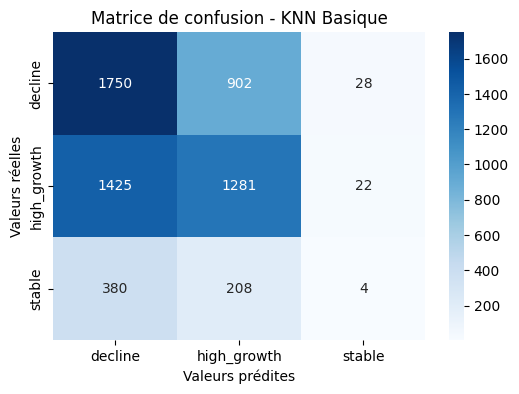

In [13]:
# Matrice de confusion
plt.figure(figsize=(6, 4))
cm_basic = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Basique")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

In [14]:
#  run time :6 minutes
print("🔍 Optimisation des hyperparamètres...")
# Recherche des meilleurs hyperparamètres
param_grid = {
    'n_neighbors': range(3, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)

# Meilleur modèle
best_knn = knn_grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

# Évaluation du modèle optimisé
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Meilleur KNN - Précision : {acc_best:.3f}")
print(f" Meilleurs paramètres : {knn_grid.best_params_}")


🔍 Optimisation des hyperparamètres...


Meilleur KNN - Précision : 0.566
 Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}



Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

     decline       0.54      0.71      0.61      2680
 high_growth       0.61      0.54      0.58      2728
      stable       0.03      0.00      0.00       592

    accuracy                           0.57      6000
   macro avg       0.39      0.42      0.40      6000
weighted avg       0.52      0.57      0.54      6000



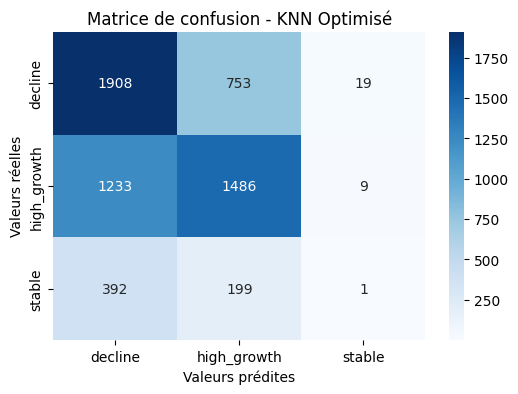

In [15]:
print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Matrice de confusion optimisée
plt.figure(figsize=(6, 4))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Optimisé")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

**Visualisation des performances**



COMPARAISON DES MODÈLES:
         Modèle  Précision                                         Paramètres
0   KNN Basique   0.505833                                                k=5
1  KNN Optimisé   0.565833  {'metric': 'manhattan', 'n_neighbors': 14, 'we...


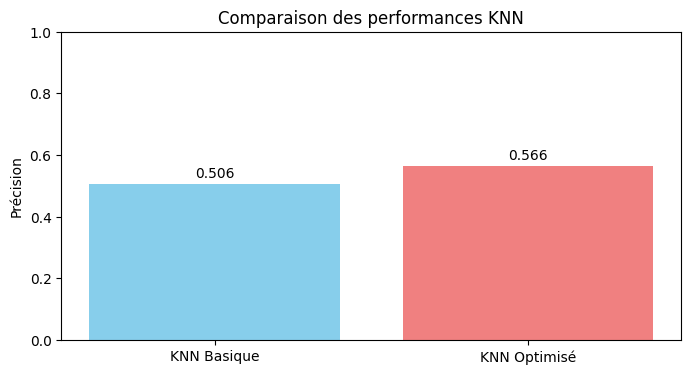

In [16]:
models_comparison = pd.DataFrame({
    'Modèle': ['KNN Basique', 'KNN Optimisé'],
    'Précision': [acc_basic, acc_best],
    'Paramètres': ['k=5', str(knn_grid.best_params_)]
})

print("\nCOMPARAISON DES MODÈLES:")
print(models_comparison)

# Graphique de comparaison
plt.figure(figsize=(8, 4))
plt.bar(models_comparison['Modèle'], models_comparison['Précision'], color=['skyblue', 'lightcoral'])
plt.title('Comparaison des performances KNN')
plt.ylabel('Précision')
plt.ylim(0, 1)
for i, v in enumerate(models_comparison['Précision']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.show()

**Analyse de l'impact du nombre de voisins**

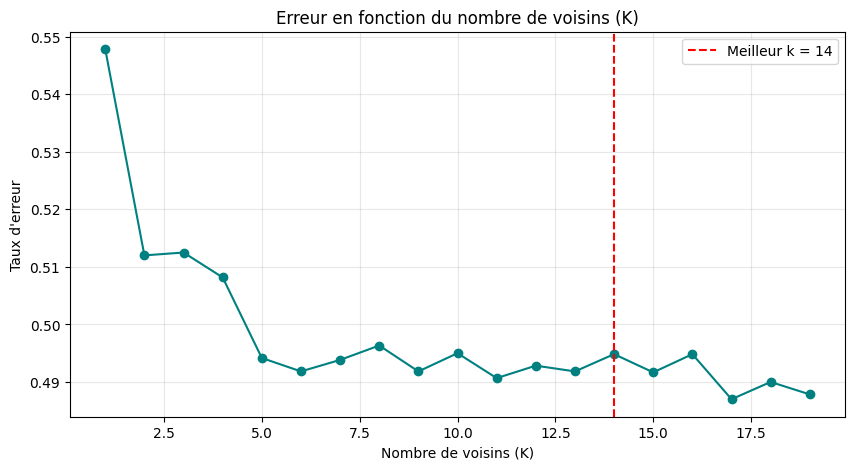

In [17]:
errors = []
neighbors_range = range(1, 20)

for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred_k = model.predict(X_test)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.figure(figsize=(10, 5))
plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal')
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}')
plt.title("Erreur en fonction du nombre de voisins (K)")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **Modèle Arbre de Décision** 


In [24]:
# **ARBRE DE DÉCISION - BO1 Classification**
print("\n" + "="*50)
print("ARBRE DE DÉCISION - Classification des métiers")
print("="*50)

# **1. Importer les bibliothèques nécessaires**
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# **2. Préparer les données**
X_train_tree = X_train
X_test_tree = X_test
y_train_tree = y_train
y_test_tree = y_test

print(f"Shape X_train: {X_train_tree.shape}")
print(f"Shape y_train: {y_train_tree.shape}")
print(f"Classes: {le.classes_}")

# **3. Visualiser la data**
plt.figure(figsize=(8, 6))

# Prendre les 2 premières features pour la visualisation
feature1 = X_train_tree.columns[0]
feature2 = X_train_tree.columns[1]

for class_label in np.unique(y_train_tree):
    mask = y_train_tree == class_label
    plt.scatter(X_train_tree[mask][feature1], X_train_tree[mask][feature2], 
                alpha=0.6, label=f'{le.inverse_transform([class_label])[0]}', s=20)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Visualisation des données - Features vs Classes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **4. Entrainer le modèle**
print("\nEntraînement du modèle Arbre de Décision...")
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4  # Limiter la profondeur pour éviter l'overfitting
)
tree.fit(X_train_tree, y_train_tree)

print("✅ Modèle entraîné!")
print(f"Profondeur de l'arbre: {tree.get_depth()}")
print(f"Nombre de feuilles: {tree.get_n_leaves()}")

# **5. Faire des prédictions**
y_pred_tree = tree.predict(X_test_tree)

print("\nPremières 5 prédictions:")
for i in range(5):
    actual = le.inverse_transform([y_test_tree.iloc[i]])[0]
    predicted = le.inverse_transform([y_pred_tree[i]])[0]
    print(f"  Exemple {i+1}: Réel={actual}, Prédit={predicted}")

# **6. Evaluer le modèle**
print("\nÉVALUATION DU MODÈLE")

# 6.1 Précision
acc_tree = accuracy_score(y_test_tree, y_pred_tree)
print(f"✅ Précision: {acc_tree:.4f}")

# 6.2 Rapport détaillé
print("\nRapport de classification:")
print(classification_report(y_test_tree, y_pred_tree, target_names=le.classes_))

# 6.3 Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_tree, y_pred_tree)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
plt.title('Matrice de Confusion - Arbre de Décision')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel('Prédit')
plt.ylabel('Réel')

# Ajouter les nombres dans les cases
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# **7. Visualisation de l'arbre de décision**
print("\n🌳 VISUALISATION DE L'ARBRE DE DÉCISION")

plt.figure(figsize=(20, 10))
plot_tree(tree,
          filled=True,
          feature_names=X_train_tree.columns,
          class_names=le.classes_,
          fontsize=10,
          max_depth=3)  # Montrer seulement les 3 premiers niveaux pour la lisibilité
plt.title('Arbre de Décision - 3 premiers niveaux')
plt.show()

# **8. Importance des caractéristiques**
print("\n🔍 IMPORTANCE DES CARACTÉRISTIQUES")

# Créer un DataFrame pour l'importance des features
feature_importance = pd.Series(tree.feature_importances_, index=X_train_tree.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Top 10 caractéristiques les plus importantes:")
for i, (feature, importance) in enumerate(feature_importance.head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

# Visualisation de l'importance des features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Importance')
plt.title('Top 15 - Importance des Caractéristiques\n(Arbre de Décision)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# **9. Visualisation des résultats**
plt.figure(figsize=(10, 4))

# Graphique 1: Comparaison réel vs prédit
plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test_tree[:50])), y_test_tree[:50], color='blue', label='Réel', alpha=0.6)
plt.scatter(range(len(y_pred_tree[:50])), y_pred_tree[:50], color='green', label='Prédit', alpha=0.6)
plt.xlabel('Échantillons')
plt.ylabel('Classe')
plt.title('Comparaison Réel vs Prédit (50 premiers)')
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2: Distribution des prédictions
plt.subplot(1, 2, 2)
unique, counts = np.unique(y_pred_tree, return_counts=True)
plt.bar(le.inverse_transform(unique), counts, alpha=0.7, color='green')
plt.title('Distribution des Prédictions')
plt.xlabel('Classes')
plt.ylabel('Nombre')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **10. Métriques de performance**
print("\nMÉTRIQUES DE PERFORMANCE:")
print(f"Précision: {acc_tree:.4f}")

# Calculer précision par classe
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test_tree, y_pred_tree, average=None)
recall = recall_score(y_test_tree, y_pred_tree, average=None)

print("\nDétail par classe:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}")

# **11. Validation croisée**
print("\n🎯 VALIDATION CROISÉE")
from sklearn.model_selection import cross_val_score

# Validation croisée avec 5 folds
cv_scores = cross_val_score(tree, X_train_tree, y_train_tree, cv=5, scoring='accuracy')
print(f"Scores de validation croisée (5 folds): {cv_scores}")
print(f"Score moyen: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# **12. Résumé final**
print("\n" + "="*50)
print("RÉSUMÉ FINAL - ARBRE DE DÉCISION")
print("="*50)
print(f"📊 Précision globale: {acc_tree:.3f}")
print(f"🎯 Classes: {list(le.classes_)}")
print(f"🌳 Profondeur de l'arbre: {tree.get_depth()}")
print(f"🍃 Nombre de feuilles: {tree.get_n_leaves()}")
print(f"🔧 Features utilisées: {X_train_tree.shape[1]}")
print(f"📈 Échantillons d'entraînement: {X_train_tree.shape[0]}")
print(f"📊 Échantillons de test: {X_test_tree.shape[0]}")
print(f"🎯 Score validation croisée: {cv_scores.mean():.3f}")
print("="*50)

print("\n💡 INTERPRÉTATION MÉTIER:")
print("L'arbre de décision nous permet de:")
print("  • Comprendre les règles de décision pour classer les métiers")
print("  • Identifier les caractéristiques les plus discriminantes")
print("  • Obtenir un modèle interprétable et explicable")

print(f"\n📈 Caractéristiques les plus influentes:")
top_3_features = feature_importance.head(3)
for i, (feature, importance) in enumerate(top_3_features.items(), 1):
    print(f"  {i}. {feature}: {importance:.3f}")


ARBRE DE DÉCISION - Classification des métiers
Shape X_train: (24000, 7)
Shape y_train: (24000,)
Classes: ['decline' 'high_growth' 'stable']


ValueError: y contains previously unseen labels: [-1.22816078]

<Figure size 800x600 with 0 Axes>

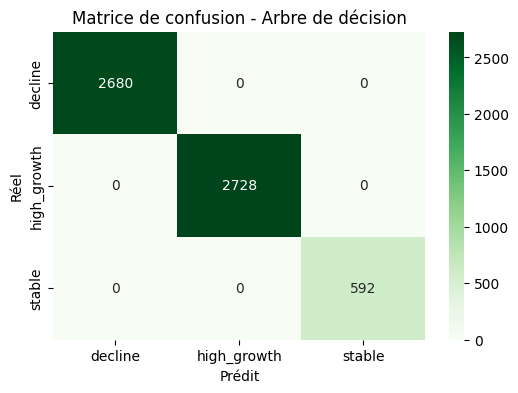

In [ ]:
# 4) Matrice de confusion
plt.figure(figsize=(6, 4))
cm_tree = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, 
            yticklabels=target_names) 
plt.title("Matrice de confusion - Arbre de décision")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

Automation Risk (%) → premier critère, donc le plus discriminant.

Job Openings (2024) et Projected Openings (2030) → reflètent la demande actuelle et future.

Median Salary (USD) → influence la prédiction, souvent sur la rentabilité ou attractivité du métier
    


Le Gini Index (ou Gini impurity) mesure à quel point un noeud est « pur » :

> 0 → le noeud contient uniquement une classe (parfaitement pur).

> 1 → les classes sont mélangées uniformément (impur).

# **Régression Linéaire**


In [ ]:
X_train_reg = X_train
X_test_reg = X_test
y_train_reg = y_train
y_test_reg = y_test
print(f"Shape X_train_reg: {X_train_reg.shape}, Shape y_train_reg: {y_train_reg.shape}")
print(f"Shape X_test_reg: {X_test_reg.shape}, Shape y_test_reg: {y_test_reg.shape}")
print(f"classes: {le.classes_}")


Shape X_train_reg: (24000, 27), Shape y_train_reg: (24000,)
Shape X_test_reg: (6000, 27), Shape y_test_reg: (6000,)
classes: ['decline' 'high_growth' 'stable']


In [ ]:
# **5. Entraîner le modèle de régression logistique**
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_reg, y_train_reg)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
print("Modèle entraîné avec succès!")
print(f"Intercept : {log_reg.intercept_}")
print(f"Coefficients: {log_reg.coef_}")

Modèle entraîné avec succès!
Intercept : [-9.96507428  9.18678526  0.77828901]
Coefficients: [[-7.97391869e-03  1.40427132e-02  5.67336716e-02 -4.04824186e-02
  -1.06461552e-02 -3.91295339e+01  1.99173273e-02  5.56701884e-02
   1.10588833e-03  4.52760942e-03  1.91188330e-02  2.75615908e-02
  -2.42266020e-02  8.60257666e-04  1.89591002e-03  8.70331210e-04
   1.01960244e-04 -1.11956054e-02  4.63146349e-03 -4.45513870e-04
   8.31683708e-04  8.62558908e-03 -1.25395272e-02  1.88160130e-03
   3.20863479e-03  4.50211190e-03 -6.08650485e-03]
 [-3.37470071e-03  6.47180263e-03  6.34621990e-03  3.63289584e-04
  -9.27417429e-03  3.69174338e+01 -2.83371455e-03  6.82507902e-03
   1.27655453e-02 -1.27552883e-02  2.08298794e-02  6.21150769e-03
   4.99969491e-03  1.96288881e-03 -1.47152565e-02 -3.53770162e-03
   6.26664533e-03  5.90490951e-03 -7.25130335e-03  1.52059015e-03
   1.90588819e-03 -5.62831075e-03 -2.61354880e-03 -1.84787459e-03
   4.19803208e-03  1.75477885e-03  7.47673639e-04]
 [ 1.13486194

In [ ]:
print("\nPRÉDICTIONS SUR L'ENSEMBLE DE TEST")
y_pred_log = log_reg.predict(X_test_reg)
print("\nPremières 5 prédictions:")
for i in range(5):
    actual = le.inverse_transform([y_test_reg.iloc[i]])[0]
    predicted = le.inverse_transform([y_pred_log[i]])[0]
    print(f"  Exemple {i+1}: Réel={actual}, Prédit={predicted}")


PRÉDICTIONS SUR L'ENSEMBLE DE TEST

Premières 5 prédictions:
  Exemple 1: Réel=high_growth, Prédit=high_growth
  Exemple 2: Réel=high_growth, Prédit=high_growth
  Exemple 3: Réel=decline, Prédit=decline
  Exemple 4: Réel=high_growth, Prédit=high_growth
  Exemple 5: Réel=high_growth, Prédit=high_growth


In [ ]:
print("\nÉVALUATION DU MODÈLE")
# 7.1 Précision globale
acc_log = accuracy_score(y_test_reg, y_pred_log)
print(f" Précision globale: {acc_log:.4f}")

# Rapport de classification détaillé
print("\nRAPPORT DE CLASSIFICATION DÉTAILLÉ:")
print(classification_report(y_test_reg, y_pred_log, target_names=le.classes_))


ÉVALUATION DU MODÈLE
 Précision globale: 0.9507

RAPPORT DE CLASSIFICATION DÉTAILLÉ:
              precision    recall  f1-score   support

     decline       0.93      1.00      0.97      2680
 high_growth       0.96      1.00      0.98      2728
      stable       1.00      0.50      0.67       592

    accuracy                           0.95      6000
   macro avg       0.97      0.83      0.87      6000
weighted avg       0.95      0.95      0.94      6000



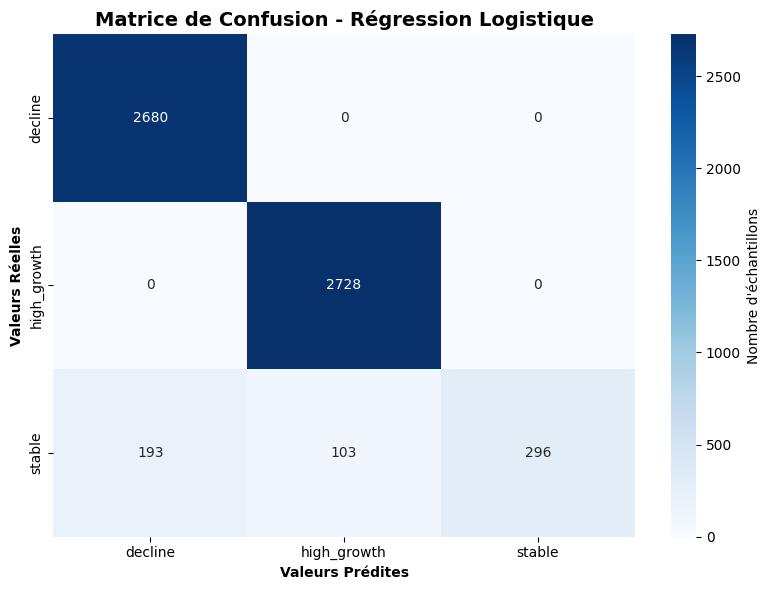

In [ ]:
# Matrice de confusion
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test_reg, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre d\'échantillons'})
plt.title('Matrice de Confusion - Régression Logistique', fontsize=14, fontweight='bold')
plt.xlabel('Valeurs Prédites', fontweight='bold')
plt.ylabel('Valeurs Réelles', fontweight='bold')
plt.tight_layout()
plt.show()

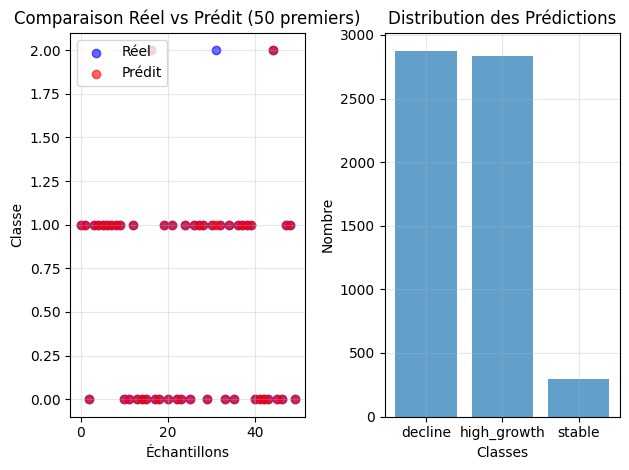

In [ ]:
# Comparaison réel vs prédit
plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test_reg[:50])), y_test_reg[:50], color='blue', label='Réel', alpha=0.6)
plt.scatter(range(len(y_pred_log[:50])), y_pred_log[:50], color='red', label='Prédit', alpha=0.6)
plt.xlabel('Échantillons')
plt.ylabel('Classe')
plt.title('Comparaison Réel vs Prédit (50 premiers)')
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2: Distribution des prédictions
plt.subplot(1, 2, 2)
unique, counts = np.unique(y_pred_log, return_counts=True)
plt.bar(le.inverse_transform(unique), counts, alpha=0.7)
plt.title('Distribution des Prédictions')
plt.xlabel('Classes')
plt.ylabel('Nombre')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nMÉTRIQUES DE PERFORMANCE:")
print(f"Précision: {acc_log:.4f}")

# Calculer précision par classe
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test_reg, y_pred_log, average=None)
recall = recall_score(y_test_reg, y_pred_log, average=None)

print("\nDétail par classe:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}")



print(f"Précision globale: {acc_log:.3f}")
print(f"🎯 Classes: {list(le.classes_)}")
print(f"Features utilisées: {X_train_reg.shape[1]}")
print(f"Échantillons d'entraînement: {X_train_reg.shape[0]}")
print(f"Échantillons de test: {X_test_reg.shape[0]}")



MÉTRIQUES DE PERFORMANCE:
Précision: 0.9507

Détail par classe:
  decline: Precision=0.933, Recall=1.000
  high_growth: Precision=0.964, Recall=1.000
  stable: Precision=1.000, Recall=0.500
Précision globale: 0.951
🎯 Classes: ['decline', 'high_growth', 'stable']
Features utilisées: 27
Échantillons d'entraînement: 24000
Échantillons de test: 6000


# **XGboost**

In [ ]:
# --- VÉRIFICATION DES COLONNES REQUISES ---
required_columns = [
    'Job_Title', 'Growth_Category', 'AI_Impact_Level'
]

missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"\nERREUR : Colonnes manquantes : {missing_cols}")
    print("Assure-toi que les noms de colonnes correspondent exactement.")
else:
    print("Toutes les colonnes nécessaires sont présentes !")

Toutes les colonnes nécessaires sont présentes !


In [ ]:
# --- PREPARATION DES DONNEES ---
# Encode the target variable 'Growth_Category'
le_growth_category = LabelEncoder()
df['Growth_Category_encoded'] = le_growth_category.fit_transform(df['Growth_Category'])

print(f"Mapping Growth Category: {dict(zip(le_growth_category.classes_, le_growth_category.transform(le_growth_category.classes_)))}")

# Features are the PCA components (PC1 to PC18)
features_bo1 = [col for col in df.columns if col.startswith('PC')]

X = df[features_bo1]
y = df['Growth_Category_encoded']

print(f"Features used for classification: {features_bo1}")
print(f"Target variable: Growth_Category")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Mapping Growth Category: {'decline': 0, 'high_growth': 1, 'stable': 2}
Features used for classification: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18']
Target variable: Growth_Category
Shape of X: (30000, 18)
Shape of y: (30000,)


In [ ]:
print("ENTRAINEMENT DU MODÈLE XGBOOST")

# Initialize and train the XGBoost Classifier
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)


ENTRAINEMENT DU MODÈLE XGBOOST


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [ ]:
# --- ÉVALUATION DU MODÈLE ---
print("ÉVALUATION DU MODÈLE")

y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_growth_category.classes_))

# Feature Importance
print("IMPORTANCE DES FEATURES")
# Get feature importance from the trained model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10).to_string(index=False))

ÉVALUATION DU MODÈLE
Accuracy: 0.6182

Classification Report:
              precision    recall  f1-score   support

     decline       0.59      0.74      0.65      2680
 high_growth       0.66      0.64      0.65      2728
      stable       0.04      0.00      0.00       592

    accuracy                           0.62      6000
   macro avg       0.43      0.46      0.44      6000
weighted avg       0.57      0.62      0.59      6000

IMPORTANCE DES FEATURES
Feature  Importance
   PC18    0.098817
    PC8    0.077257
   PC11    0.071310
   PC12    0.059819
   PC15    0.056444
   PC13    0.054403
    PC7    0.054330
   PC10    0.054085
   PC16    0.052906
    PC5    0.050339


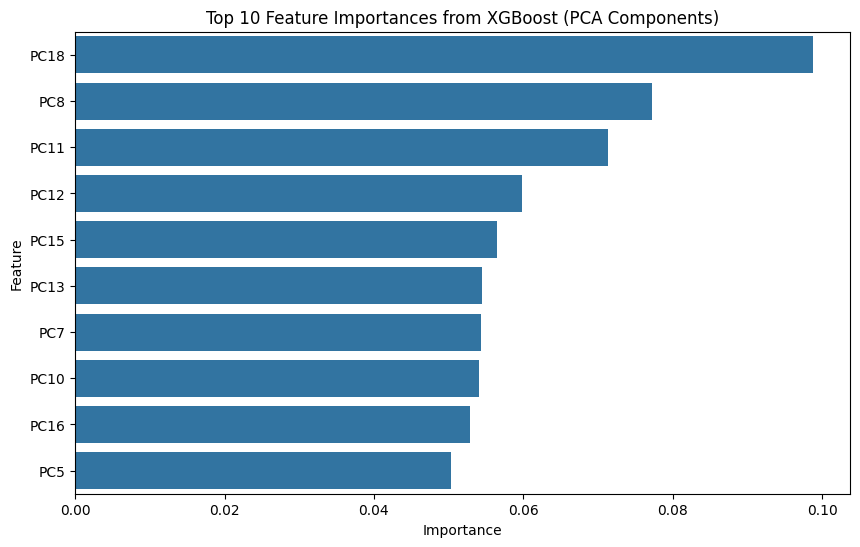

In [ ]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances from XGBoost (PCA Components)')
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

# Re-initialize the base XGBoost model
# Using the same parameters as the initial model trained in J-xlOhWt9Hwn
initial_model_bo1 = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Define K-Fold Cross-Validation
num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_scores = []

print(f"Performing {num_folds}-Fold Cross-Validation...")

for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.6197
Fold 2 Accuracy: 0.6205
Fold 3 Accuracy: 0.6205
Fold 4 Accuracy: 0.6273
Fold 5 Accuracy: 0.6170

Mean CV Accuracy: 0.6210
Std Dev CV Accuracy: 0.0034


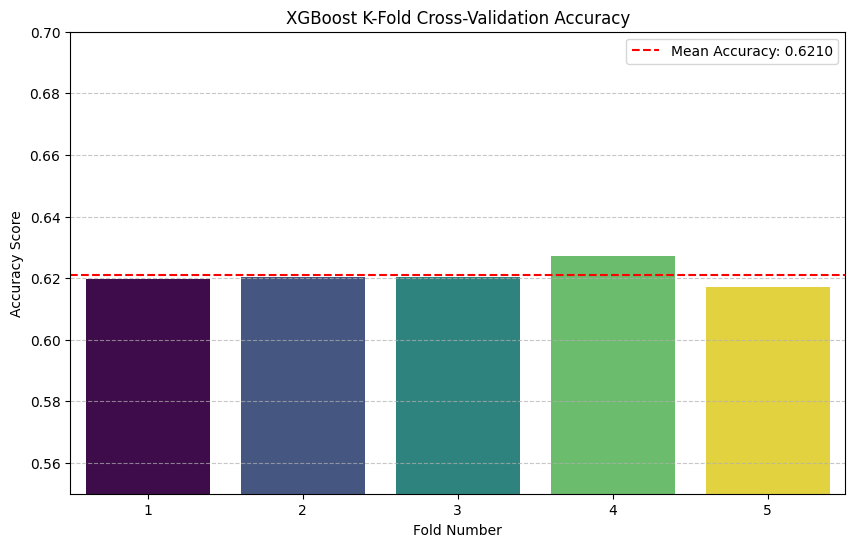

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.mean

# Create a DataFrame for plotting cross-validation scores
cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.55, 0.70) # Adjust y-axis for better visualization of scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Implement Grid Search**


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
# It's good practice to ensure the number of classes is correctly identified
num_classes = len(np.unique(y_train))
model_for_grid_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation as an example
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 # Use all available CPU cores
)

print("Starting Grid Search...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))


Starting Grid Search...
Fitting 3 folds for each of 192 candidates, totalling 576 fits


**Implement Random Search**


In [ ]:
## Implement Random Search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for XGBoost
param_distributions = {
    'n_estimators': randint(50, 200), # Number of boosting rounds
    'max_depth': randint(3, 10),      # Maximum tree depth
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
num_classes = len(np.unique(y_train))
model_for_random_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42
)

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled
random_search = RandomizedSearchCV(
    estimator=model_for_random_search,
    param_distributions=param_distributions,
    n_iter=50, # Sample 50 different parameter combinations
    cv=3,      # Using 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

print("Starting Random Search...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nRandom Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(random_search.best_score_))

Starting Random Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits



Random Search completed!
Best parameters found:  {'colsample_bytree': 0.9395655297064336, 'learning_rate': 0.22651885634946198, 'max_depth': 9, 'n_estimators': 191, 'subsample': 0.7975182385457563}
Best cross-validation accuracy: 0.6282


**Compare Search Results**




In [ ]:
# Retrieve best parameters and score from Grid Search
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

# Retrieve best parameters and score from Random Search
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print("COMPARISON OF HYPERPARAMETER SEARCH RESULTS")

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {best_params_grid}")
print(f"Best Cross-Validation Accuracy: {best_score_grid:.4f}")

print("\n--- Random Search Results ---")
print(f"Best Parameters: {best_params_random}")
print(f"Best Cross-Validation Accuracy: {best_score_random:.4f}")

print("CONCLUSION")

if best_score_grid > best_score_random:
    print(f"Grid Search yielded a better model configuration with an accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
elif best_score_random > best_score_grid:
    print(f"Random Search yielded a better model configuration with an accuracy of {best_score_random:.4f}.")
    print(f"Optimal Parameters (Random Search): {best_params_random}")
else:
    print(f"Both Grid Search and Random Search yielded the same best accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
    print(f"Optimal Parameters (Random Search): {best_params_random}")

COMPARISON OF HYPERPARAMETER SEARCH RESULTS

--- Grid Search Results ---
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Best Cross-Validation Accuracy: 0.5760

--- Random Search Results ---
Best Parameters: {'colsample_bytree': 0.9395655297064336, 'learning_rate': 0.22651885634946198, 'max_depth': 9, 'n_estimators': 191, 'subsample': 0.7975182385457563}
Best Cross-Validation Accuracy: 0.6282
CONCLUSION
Random Search yielded a better model configuration with an accuracy of 0.6282.
Optimal Parameters (Random Search): {'colsample_bytree': 0.9395655297064336, 'learning_rate': 0.22651885634946198, 'max_depth': 9, 'n_estimators': 191, 'subsample': 0.7975182385457563}


**retrain Model with Best Parameters**

In [ ]:
print("RETRAINING XGBOOST MODEL WITH BEST PARAMETERS")
# Identify the best parameters from Random Search
best_params = random_search.best_params_

# Initialize a new XGBClassifier model using these best parameters
num_classes = len(np.unique(y_train))
final_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    **best_params
)
# Train this new model using the entire training dataset
final_model.fit(X_train, y_train)

print("Final XGBoost model retrained successfully with optimal parameters!")

RETRAINING XGBOOST MODEL WITH BEST PARAMETERS
Final XGBoost model retrained successfully with optimal parameters!


**EVALUATING FINAL MODEL PERFORMANCE**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("EVALUATING FINAL MODEL PERFORMANCE ON TEST SET")

# Make predictions on the test set using the final model
y_pred_final = final_model.predict(X_test)

# Calculate overall accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")

# Generate a comprehensive classification report
print("\nClassification Report for Final Model:")
print(classification_report(y_test, y_pred_final, target_names=le_growth_category.classes_))

EVALUATING FINAL MODEL PERFORMANCE ON TEST SET
Final Model Accuracy on Test Set: 0.6508

Classification Report for Final Model:
              precision    recall  f1-score   support

     decline       0.63      0.74      0.68      2680
 high_growth       0.69      0.70      0.69      2728
      stable       0.10      0.01      0.02       592

    accuracy                           0.65      6000
   macro avg       0.47      0.48      0.47      6000
weighted avg       0.60      0.65      0.62      6000

